## Topic 1: Why Self-Attention is Called "Self" – Comparison with Luong Attention

---

### 1. Introduction

**What it is:**  
This topic explains the naming of **Self-Attention** – why it is called "attention" and why it is called "self". It does this by comparing Self-Attention with an earlier attention mechanism called **Luong Attention** (a type of encoder-decoder attention used in machine translation).

**Why it's important:**  
- This is a common interview question.  
- Understanding this comparison reveals that Self-Attention isn't a completely new idea; it reuses the same mathematical core as earlier attention, just in a different setting.  
- It builds a bridge from traditional sequence-to-sequence models to the Transformer architecture.

**Real-life use:**  
- Traditional attention (Luong/Bahdanau) was used in **machine translation** (e.g., English → Hindi).  
- Self-Attention is used inside **Transformers**, which power models like GPT, BERT, and modern translation systems. Understanding why it's called "self" helps you grasp why Transformers process entire sentences differently.

---

### 2. Detailed Explanation

#### Step 1: Recap of Traditional Attention (Luong Attention)
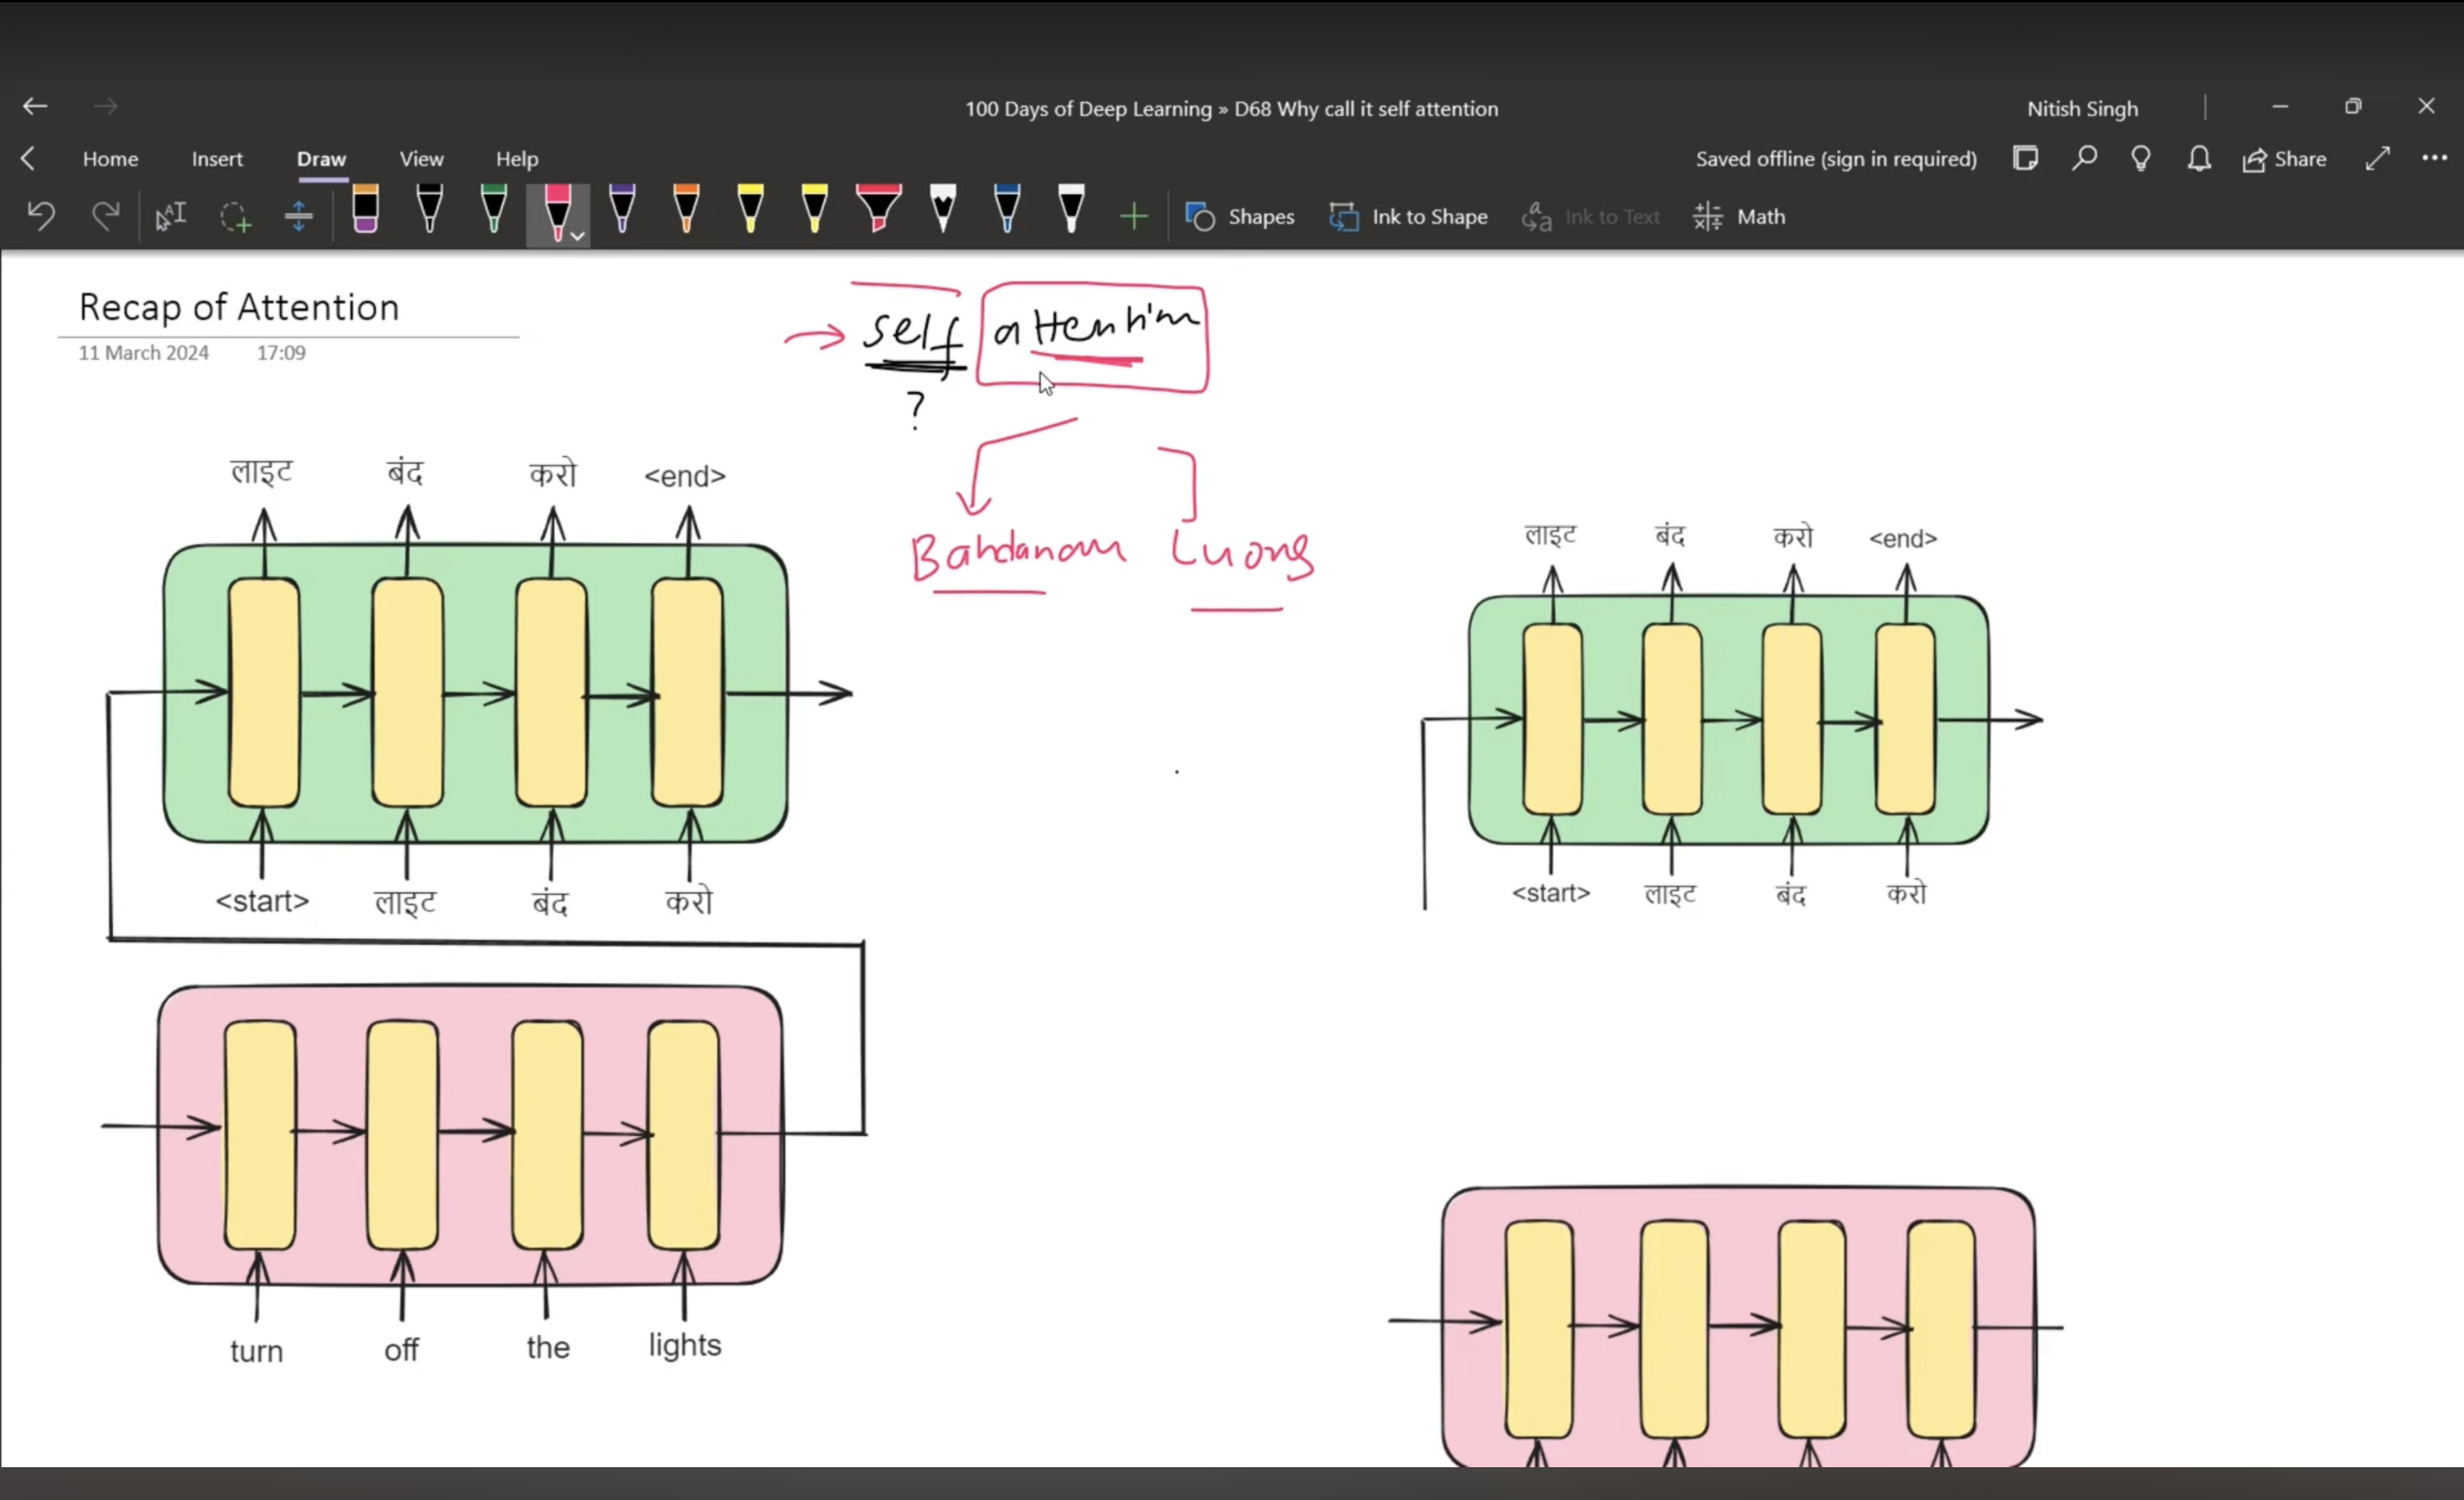
In sequence-to-sequence tasks (like translation), we use an **Encoder-Decoder** architecture:

- **Encoder:** Reads the input sentence (e.g., English) word by word using LSTMs. After reading all words, it produces a final hidden state called the **context vector**, which summarises the entire sentence.
- **Decoder:** Takes this context vector and generates the output sentence (e.g., Hindi) word by word.

**The problem:**  
For long sentences (>30 words), a single context vector cannot effectively summarise all information. Translation quality drops.

**The attention solution:**  
Instead of one fixed context vector for the whole output, attention creates a **separate context vector for each output time step**. Each context vector focuses on the most relevant input words for that specific output word.

**How Luong Attention works (mathematically):**

For each decoder time step *i* and encoder time step *j*:

1. **Alignment score** (*eᵢⱼ*):
   - Calculated as: **dot product** of decoder hidden state (*sᵢ*) and encoder hidden state (*hⱼ*).
   - `eᵢⱼ = sᵢ · hⱼ`
   - Higher score = stronger relevance.

2. **Attention weights** (*αᵢⱼ*):
   - Apply **softmax** over all alignment scores for a fixed *i*:
   - `αᵢⱼ = softmax(eᵢⱼ)` → ensures weights sum to 1.

3. **Context vector** (*cᵢ*):
   - Weighted sum of encoder hidden states using the attention weights:
   - `cᵢ = Σⱼ αᵢⱼ · hⱼ`

**Key observation:**  
- The decoder hidden state (*sᵢ*) **queries** the encoder hidden states (*hⱼ*).  
- Encoder states act as **keys** that respond with similarity scores.  
- The weighted sum produces a **value** (context vector).  

> **Analogy:** Imagine you're writing a Hindi translation of an English sentence. When you need to write the first Hindi word, you "query" the English words: "Which English word is most relevant right now?" The English words "answer" with scores, and you pay most attention to the highest-scoring one.

---

#### Step 2: How Self-Attention Works (Side-by-Side Comparison)
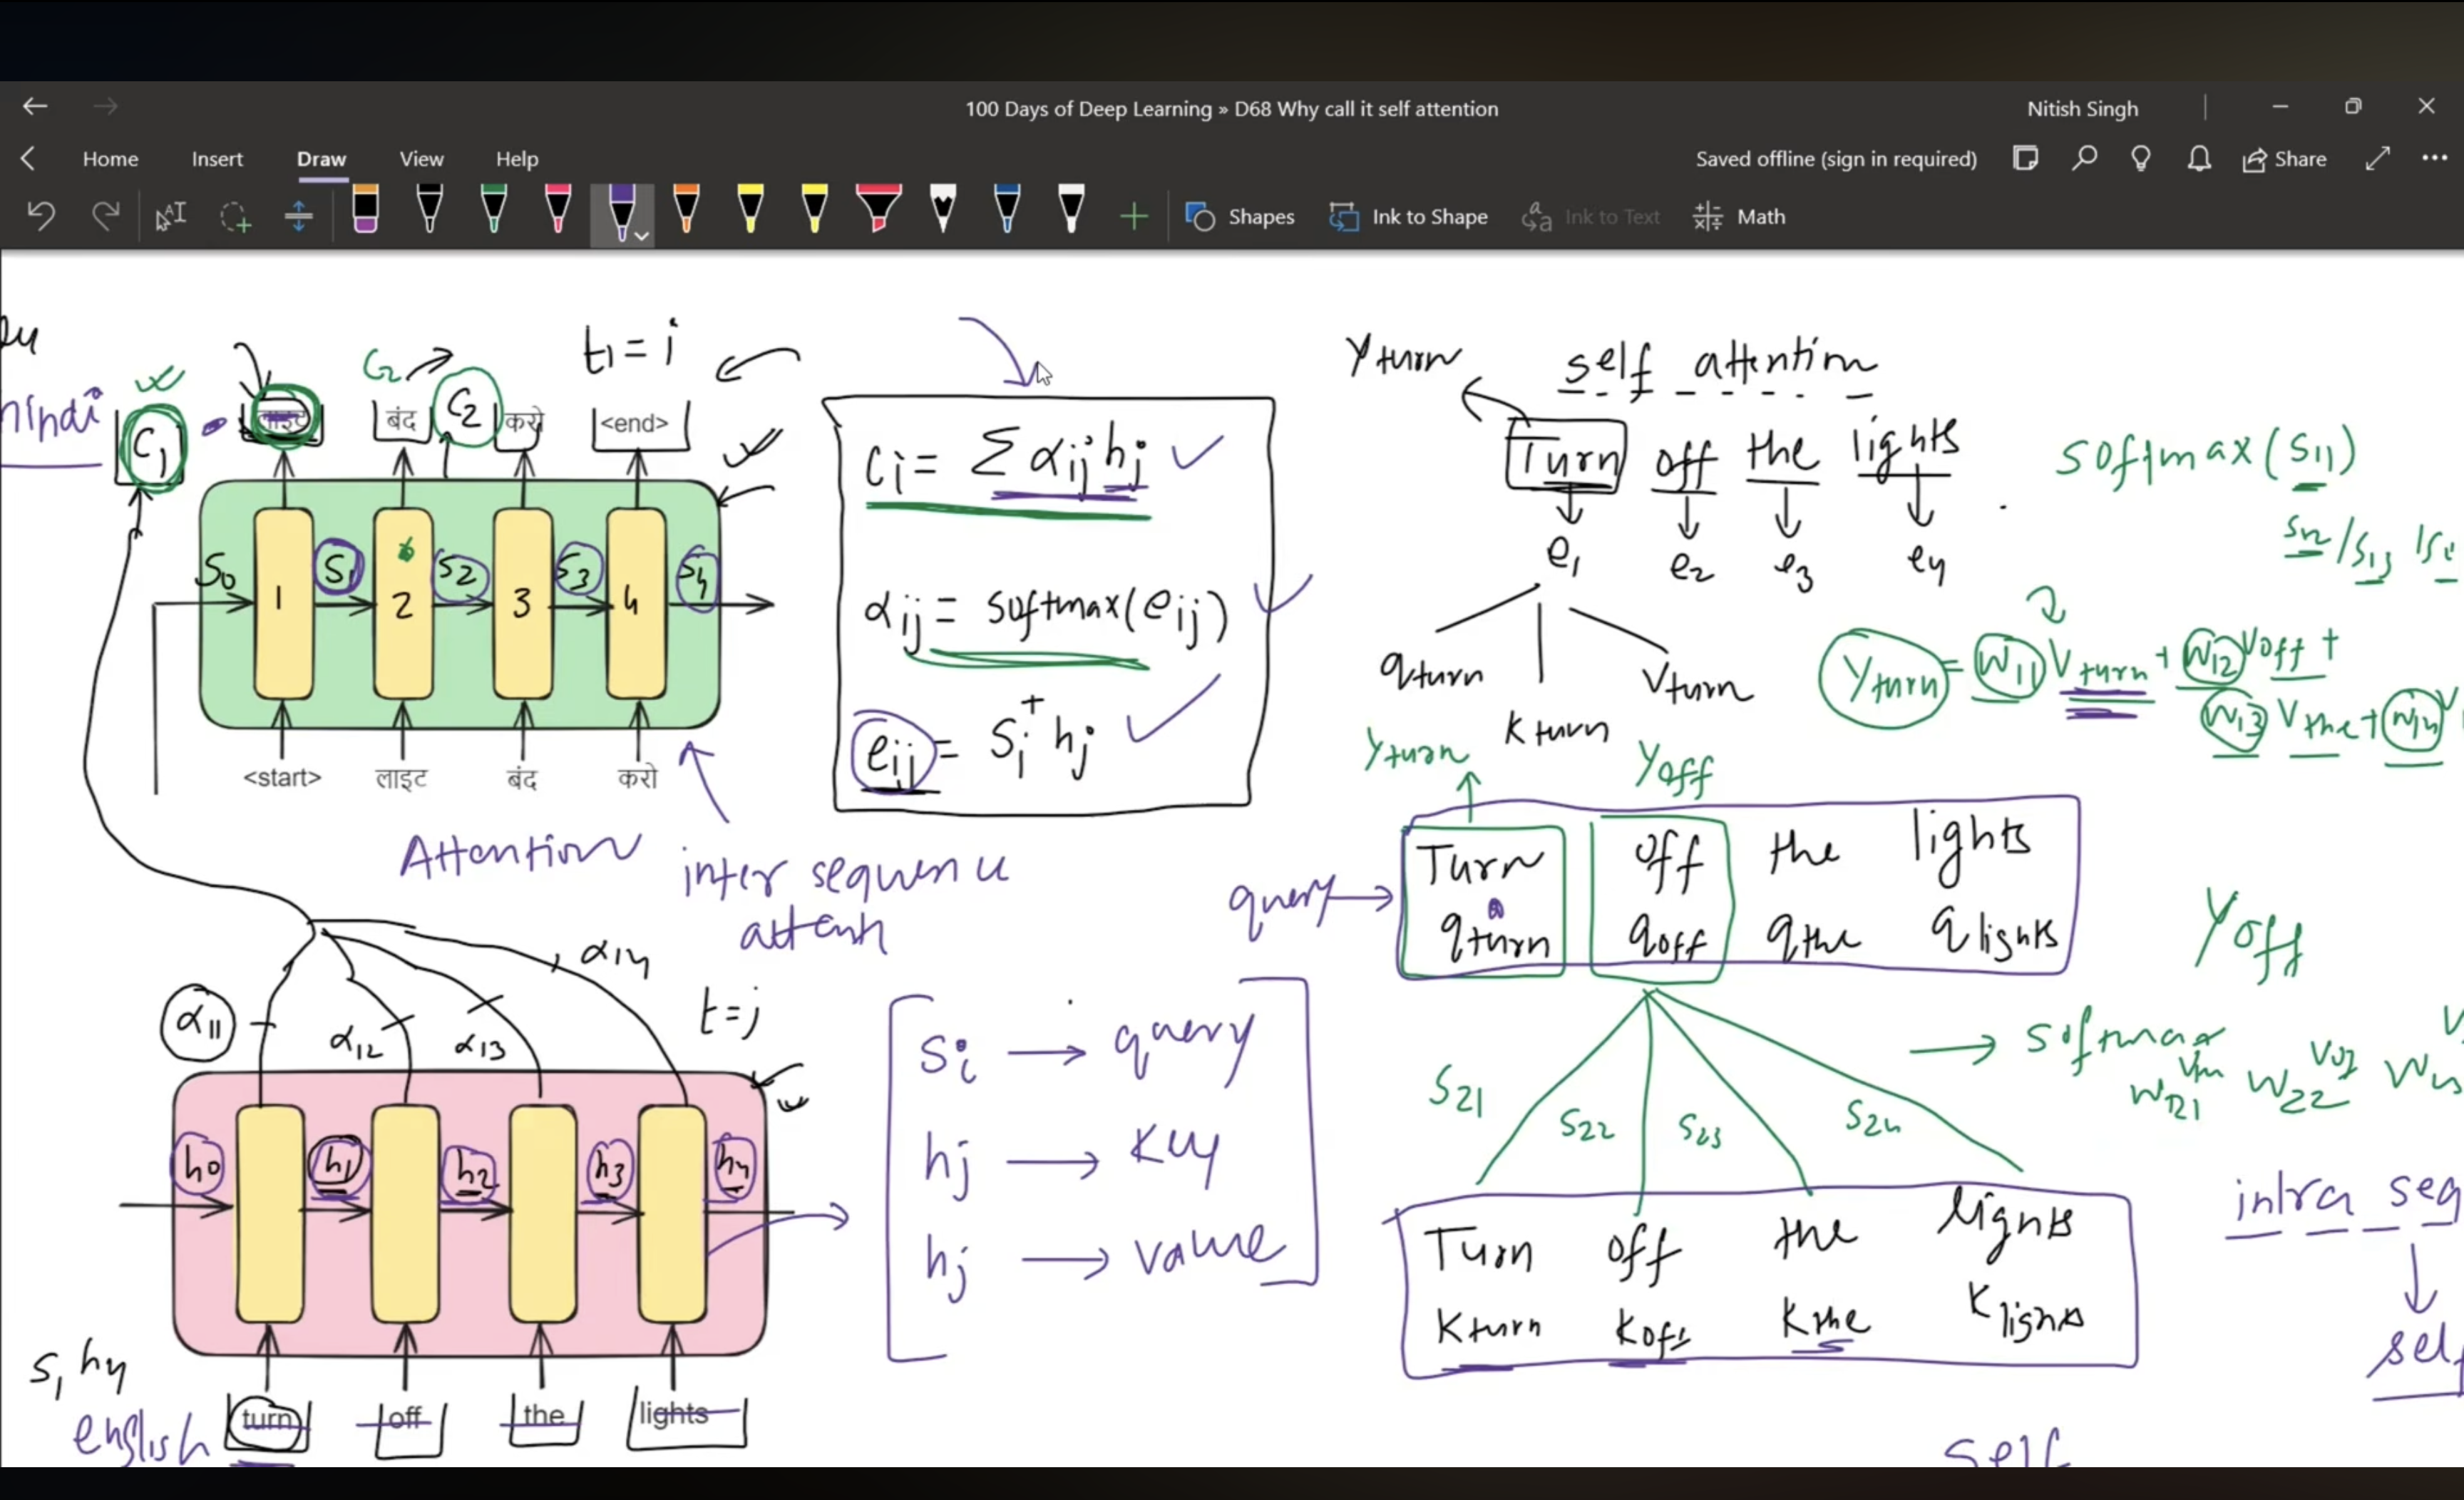
Now consider Self-Attention. There is **no encoder or decoder** – just a single sentence, e.g., *"turn off the lights"*.

We have:
- Each word's **embedding vector** (from Word2Vec or similar).
- From each embedding, we create **three new vectors**:
  - **Query (q)** – asks: "How relevant am I to others?"
  - **Key (k)** – answers: "How relevant are others to me?"
  - **Value (v)** – holds the actual content to be aggregated.

**To generate the contextual embedding for the first word "turn":**

| Step | Action | Formula |
|------|--------|---------|
| 1 | Compute similarity of `q_turn` with all keys | `s₁₁ = q_turn · k_turn`<br>`s₁₂ = q_turn · k_off`<br>`s₁₃ = q_turn · k_the`<br>`s₁₄ = q_turn · k_lights` |
| 2 | Normalise to weights | `w₁₁, w₁₂, w₁₃, w₁₄ = softmax(s₁₁, s₁₂, s₁₃, s₁₄)` |
| 3 | Weighted sum of values | `c₁ = w₁₁·v_turn + w₁₂·v_off + w₁₃·v_the + w₁₄·v_lights` |

Similarly, for "off", you use `q_off` with all keys, get weights, and form `c₂`.

---

#### Step 3: Drawing the Parallel

| Traditional Luong Attention | Self-Attention |
|-----------------------------|----------------|
| Decoder hidden state (`sᵢ`) acts as **query** | Query vector of current word acts as **query** |
| Encoder hidden states (`hⱼ`) act as **keys** | Key vectors of all words act as **keys** |
| Dot product gives **alignment score** (`eᵢⱼ`) | Dot product gives **similarity score** (`sᵢⱼ`) |
| Softmax normalises to **weights** (`αᵢⱼ`) | Softmax normalises to **weights** (`wᵢⱼ`) |
| Weighted sum of encoder states = **context vector** | Weighted sum of value vectors = **contextual embedding** |

**Conclusion:**  
The three core equations – (1) dot product, (2) softmax, (3) weighted sum – are **identical** in both mechanisms. That is why Self-Attention is still called **attention**.

---

#### Step 4: Why "Self"?

- In **Luong/Bahdanau attention**, attention is calculated **between two different sequences** (source English sentence and target Hindi sentence). This is called **inter-sequence** attention.
- In **Self-Attention**, the queries, keys, and values all come from **the same sequence** (the sentence *"turn off the lights"*). This is called **intra-sequence** attention.

> **Analogy:** Traditional attention is like asking a group of people (English words) for help while you're in another group (Hindi words). Self-attention is like each member of a single group asking every other member in the same group, "How relevant are you to me?"

---

### 3. Key Points

- Traditional attention (Luong) uses decoder states as queries and encoder states as keys/values – **two sequences**.
- Self-Attention uses query, key, and value vectors derived from **the same sequence**.
- Both share the same three-step mathematical process:
  1. Dot product (similarity/alignment)
  2. Softmax (normalisation into weights)
  3. Weighted sum (aggregation)
- Because the process is mathematically identical, Self-Attention is a form of attention.
- Because it operates on a single sequence, it is called **self**-attention.

---

### 4. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|--------------|
| Thinking Self-Attention is a completely new idea unrelated to older attention | It reuses the same three equations; only the inputs change | Always trace back the mathematical steps – dot product → softmax → weighted sum |
| Confusing "query" in Self-Attention with "query" in databases | In Self-Attention, query is a learned vector that computes relevance, not a database search query | Remember: query here means "asking for relevance scores" |
| Assuming Self-Attention requires an encoder-decoder | It works on a single sequence; no encoder or decoder is needed | Focus on the inputs: only embeddings and three derived vectors |

---

### 5. Interview/Exam Questions

**Q1:** Why is Self-Attention called an attention mechanism when it doesn't use an encoder-decoder?  
**A:** Because the core mathematical formulation – dot product of query and key, softmax to get weights, and weighted sum of values – is exactly the same as in Luong/Bahdanau attention. The architecture differs, but the operation is the same.

**Q2:** What is the difference between inter-sequence and intra-sequence attention?  
**A:** Inter-sequence attention (e.g., Luong) computes relevance between two different sequences (source and target). Intra-sequence attention (Self-Attention) computes relevance within the same sequence (all words attend to all words).

**Q3:** In Self-Attention, what do query, key, and value represent conceptually?  
**A:**  
- **Query:** Asks "How relevant am I to other words?"  
- **Key:** Answers "How relevant are other words to me?"  
- **Value:** Holds the actual information to be aggregated after weighting.

**Q4:** If I remove the softmax step from Self-Attention, what happens?  
**A:** The weights would no longer sum to 1, making the weighted sum scale inconsistently. The model would not treat attention as a probability distribution over the sequence.

---

### 6. Revision Notes (Quick Recap)

- Luong attention: `e = s · h` → `α = softmax(e)` → `c = Σ α·h`
- Self-Attention: `s = q · k` → `w = softmax(s)` → `c = Σ w·v`
- Same three equations → same name "attention"
- Luong: two sequences (encoder ↔ decoder)  
- Self: one sequence (word ↔ word in same sentence) → called "self"
- No encoder/decoder in Self-Attention – just embeddings and learned Q, K, V vectors.

---

**That concludes this topic.**  


## Topic 2: The Problem with Traditional Encoder-Decoder (Why Attention Was Needed)

---

### 1. Introduction

**What it is:**  
This topic explains the fundamental limitation of early sequence-to-sequence (Seq2Seq) models that led to the invention of the attention mechanism. It covers the **encoder-decoder architecture** with LSTMs, the concept of a **context vector**, and why this approach fails for long sentences.

**Why it's important:**  
- It gives the **motivation** behind attention mechanisms. Without understanding this problem, you won't appreciate why attention (including Self-Attention) was a breakthrough.  
- It's a common foundational question in interviews: "Why was attention introduced in machine translation?"

**Real-life use:**  
- Early neural machine translation (e.g., Google Translate in 2014–2015) used this encoder-decoder setup and suffered from quality drops on long sentences.  
- Attention fixed this, and modern systems (Transformers) are built on that fix.

---

### 2. Detailed Explanation

#### Step 1: The Task – Sequence-to-Sequence Translation

Imagine you are building a system that translates English sentences into Hindi.

- Input: An English sentence (sequence of words).  
- Output: A Hindi sentence (sequence of words).  
- This is called a **sequence-to-sequence (Seq2Seq)** task.

To solve this, researchers used an **Encoder-Decoder architecture**.

---

#### Step 2: The Encoder-Decoder Architecture

**Encoder:**
- Takes the input sentence word by word.
- Uses **LSTM** (Long Short-Term Memory) or RNN cells.
- Processes each word and updates a **hidden state**.
- After reading the **entire** sentence, it produces a final hidden state.

**Example:**  
For the sentence *"turn off the lights"* (4 words):

- Start with initial hidden state `h₀`.
- Read "turn" → produce `h₁`.
- Read "off" → produce `h₂`.
- Read "the" → produce `h₃`.
- Read "lights" → produce `h₄` (final hidden state).

**Context Vector:**
- `h₄` is called the **context vector**.
- It is a fixed-size vector (a set of numbers) that is supposed to **summarise the entire input sentence** – its meaning, grammar, and all relevant information.
- This context vector is then passed to the decoder.

**Decoder:**
- Takes the context vector as its initial state.
- Generates the output sentence word by word (e.g., "बत्ती", "बंद", "करो").
- At each step, it uses the same context vector to produce the next word.

> **Analogy:** Imagine you read a whole book and then try to summarise it in a single paragraph. You then give that paragraph to a friend who must write a translation of the entire book from just that summary. If the book is short, it works. If the book is long, you'll forget details.

---

#### Step 3: The Bottleneck – Fixed-Size Context Vector

The critical problem is that the context vector has **fixed size** (e.g., 256 numbers), regardless of input length.

| Input Length | Problem |
|--------------|---------|
| Short (5–10 words) | The context vector can capture most information. Translation quality is good. |
| Medium (15–20 words) | The vector starts to get overloaded. Some nuances are lost. Quality degrades slightly. |
| Long (>30 words) | The vector cannot possibly summarise all relationships, tenses, and meanings. Translation quality **deteriorates significantly**. |

**Why does this happen?**
- A vector of numbers has limited capacity.  
- Compressing a 30-word sentence into 256 numbers means losing information – like compressing a high-resolution image into a tiny thumbnail.  
- The decoder relies solely on this single vector, so if it's incomplete, the output suffers.

**Research finding:**  
Researchers observed that when input sentences exceeded about 30 words, BLEU scores (translation quality metrics) dropped sharply. The model simply could not remember or represent all the necessary details.

---

#### Step 4: The Attention Solution – Intuition

Instead of forcing the entire sentence into one vector, **attention** proposes:

> At each output step, let the decoder look back at **all** encoder hidden states, decide which ones are most relevant for the current word, and build a **custom context vector** on the fly.

This is like:
- Instead of giving your friend a single book summary, you give them **access to the whole book**.
- For each sentence they translate, they can flip to the relevant page and read just that part.
- No single vector has to remember everything – the information stays in the encoder states.

**Key insight:**  
Attention **removes the bottleneck** by allowing dynamic, step-specific access to the full input sequence.

---

### 3. Key Points

- Seq2Seq models with encoder-decoder use a **single context vector** to summarise the entire input.
- This context vector is the **final hidden state** of the encoder.
- For long sentences (>30 words), this vector **cannot retain enough information**, causing poor translations.
- **Attention** solves this by creating a **new context vector at each decoder step**, focusing on different parts of the input.
- Attention effectively gives the decoder **direct access** to all encoder hidden states, not just the final one.

---

### 4. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|--------------|
| Thinking the context vector is the only information passed to the decoder | That's true for basic Seq2Seq, but attention adds more: it passes *all* encoder states, then selects from them. | Remember: in attention, the decoder sees all hidden states, not just the final one. |
| Believing the problem is with LSTM capacity | LSTM can theoretically handle long sequences, but the *bottleneck is the fixed-size vector* after the final step. | Distinguish between "LSTM can process long sequences" and "a single vector can summarise long sequences." |
| Confusing encoder hidden states with context vector | All hidden states (`h₁`, `h₂`, `h₃`, `h₄`) exist. The context vector is just `h₄` (the last one). | Context vector = final hidden state only, not all of them. |

---

### 5. Interview/Exam Questions

**Q1:** What was the main problem with the basic encoder-decoder model for machine translation?  
**A:** It compressed the entire input sentence into a single fixed-size context vector (the final encoder hidden state). For long sentences, this vector could not retain all necessary information, causing translation quality to drop.

**Q2:** How did attention address this problem?  
**A:** Attention allowed the decoder to access **all** encoder hidden states at each output step, computing a weighted sum to create a **custom context vector** per step. This meant no single vector had to remember everything.

**Q3:** Why doesn't the encoder just use a larger context vector to fix the problem?  
**A:** Even with a larger vector, the size is still fixed and finite. For arbitrarily long sentences, any fixed size will eventually be insufficient. Attention provides a scalable solution because it uses all hidden states directly.

**Q4:** In the encoder-decoder, what does the decoder actually receive as input?  
**A:** In the basic model, the decoder receives only the final context vector (`h₄`) as its initial state. In attention-based models, it also receives all encoder hidden states to compute relevance scores.

---

### 6. Revision Notes (Quick Recap)

- **Task:** Translate English → Hindi using Seq2Seq.
- **Architecture:** Encoder (LSTM) + Decoder (LSTM).
- **Encoder** reads words → produces hidden states `h₁, h₂, ..., hₙ`.
- **Context vector** = final hidden state `hₙ` – a fixed-size summary.
- **Problem:** For long sentences (>30 words), the summary is too compressed; quality drops.
- **Solution (Attention):** Don't summarise everything into one vector. Let the decoder look at all `hⱼ` and decide which are relevant for each output word.
- This was the **birth of attention** – and later, Self-Attention reused the same idea but within a single sequence.

---

**That concludes this topic.**  


## Topic 3: The Three Equations of Luong Attention (Alignment Scores, Weights, Context Vector)

---

### 1. Introduction

**What it is:**  
This topic covers the **mathematical formulation** of Luong Attention – the three core equations that define how attention works in the encoder-decoder setting. These equations compute alignment scores, convert them to weights, and produce a context vector.

**Why it's important:**  
- These three equations are the **heart of all attention mechanisms**.  
- Understanding them clearly is essential because Self-Attention uses **exactly the same three equations** – just with different inputs.  
- Interviewers often ask you to write these equations or explain what each component means.

**Real-life use:**  
- Luong Attention was used in machine translation systems before Transformers.  
- Even today, understanding these equations helps you read research papers and implement attention from scratch.

---

### 2. Detailed Explanation

#### Overview: The Three Equations

| Step | Equation | Purpose |
|------|----------|---------|
| 1 | **Alignment score:** `eᵢⱼ = sᵢ · hⱼ` | Measures relevance between decoder state `i` and encoder state `j` |
| 2 | **Attention weights:** `αᵢⱼ = softmax(eᵢⱼ)` | Converts scores into probabilities that sum to 1 |
| 3 | **Context vector:** `cᵢ = Σⱼ αᵢⱼ · hⱼ` | Weighted sum of encoder states for output step `i` |

Let's break down each equation in detail.

---

#### Equation 1: Alignment Score (`eᵢⱼ`)

**Formula:**  
`eᵢⱼ = sᵢ · hⱼ`

- `sᵢ` = hidden state of the **decoder** at time step `i` (e.g., when generating the 1st, 2nd, or 3rd Hindi word).
- `hⱼ` = hidden state of the **encoder** at time step `j` (e.g., for the 1st, 2nd, 3rd, or 4th English word).
- `·` = **dot product** – a simple mathematical operation that multiplies corresponding numbers and sums them. A higher dot product means the two vectors are more "similar" or "aligned".

**What it tells you:**  
The alignment score answers: *"How relevant is the j-th input word (encoder state) for generating the i-th output word (decoder state)?"*

**Example:**  
For the sentence *"turn off the lights"* (4 encoder states: `h₁, h₂, h₃, h₄`) and generating the first output word (decoder state `s₁`), we compute:

- `e₁₁ = s₁ · h₁` → relevance of "turn" for first output word  
- `e₁₂ = s₁ · h₂` → relevance of "off" for first output word  
- `e₁₃ = s₁ · h₃` → relevance of "the" for first output word  
- `e₁₄ = s₁ · h₄` → relevance of "lights" for first output word  

If `e₁₂` is the highest, it means "off" is most relevant for generating the first Hindi word.

> **Analogy:** You have a decoder that's about to write the first Hindi word. It "asks" each English word: "How helpful are you right now?" Each word gives a score. The dot product is how we calculate that score.

---

#### Equation 2: Attention Weights (`αᵢⱼ`)

**Formula:**  
`αᵢⱼ = softmax(eᵢⱼ)`

- **Softmax** is a function that takes a list of numbers and turns them into probabilities.
- It ensures that:
  - All weights are between 0 and 1.
  - All weights for a given `i` sum to exactly 1.
- The formula for softmax over a set of scores is:  
  `αᵢⱼ = exp(eᵢⱼ) / Σₖ exp(eᵢₖ)`  
  (Higher scores get exponentially more weight.)

**Example (continuing from above):**  
Suppose the alignment scores for the first output word are:  
`e₁₁ = 0.2, e₁₂ = 2.5, e₁₃ = 0.1, e₁₄ = 0.3`

After softmax, we might get:  
`α₁₁ = 0.08, α₁₂ = 0.82, α₁₃ = 0.07, α₁₄ = 0.03`

Interpretation: The first output word should pay **82% attention** to "off", 8% to "turn", and very little to the others.

**Why softmax?**  
- It makes the weights interpretable as a **probability distribution** over input words.  
- It allows the model to "decide" which input words to focus on for each output step.

---

#### Equation 3: Context Vector (`cᵢ`)

**Formula:**  
`cᵢ = Σⱼ αᵢⱼ · hⱼ`

- `cᵢ` = context vector for decoder time step `i`.
- We multiply each encoder hidden state `hⱼ` by its attention weight `αᵢⱼ`.
- Then we **sum** all of them.

**Interpretation:**  
The context vector is a **weighted average** of all encoder hidden states. The weights determine which encoder states contribute more to the current output step.

**Example (with the numbers above):**  
`c₁ = 0.08·h₁ + 0.82·h₂ + 0.07·h₃ + 0.03·h₄`

Since `h₂` ("off") has the largest weight, `c₁` will be heavily influenced by the hidden state of "off". This context vector is then fed into the decoder to generate the first Hindi word.

> **Analogy:** You're writing your translation. Instead of using a single fixed summary, you take a weighted average of all the English words' hidden states – most weight goes to the word that's most relevant right now.

---

#### Summary Table: All 16 Alignment Scores and Weights

For an input of 4 words and an output of 4 words, we compute a full matrix:

|       | j=1 (turn) | j=2 (off) | j=3 (the) | j=4 (lights) |
|-------|------------|-----------|-----------|--------------|
| i=1   | e₁₁ → α₁₁  | e₁₂ → α₁₂ | e₁₃ → α₁₃ | e₁₄ → α₁₄   |
| i=2   | e₂₁ → α₂₁  | e₂₂ → α₂₂ | e₂₃ → α₂₃ | e₂₄ → α₂₄   |
| i=3   | e₃₁ → α₃₁  | e₃₂ → α₃₂ | e₃₃ → α₃₃ | e₃₄ → α₃₄   |
| i=4   | e₄₁ → α₄₁  | e₄₂ → α₄₂ | e₄₃ → α₄₃ | e₄₄ → α₄₄   |

- Each row `i` corresponds to one decoder step (one output word).
- Each column `j` corresponds to one encoder state (one input word).
- Softmax is applied **row-wise** – so each row sums to 1.

---

### 3. Key Points

- **Equation 1** (`eᵢⱼ = sᵢ · hⱼ`): Computes similarity/relevance between decoder and encoder states using dot product.
- **Equation 2** (`αᵢⱼ = softmax(eᵢⱼ)`): Normalises scores into probabilities that sum to 1.
- **Equation 3** (`cᵢ = Σⱼ αᵢⱼ · hⱼ`): Creates a custom context vector as a weighted sum of encoder states.
- These three equations are **universal** – Self-Attention uses the exact same form, just with different inputs (queries, keys, values all from the same sequence).

---

### 4. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|--------------|
| Applying softmax across the wrong dimension | Softmax must be applied **row-wise** (over `j` for each fixed `i`), not column-wise or globally. | Remember: for each decoder step `i`, the weights over all encoder states must sum to 1. |
| Confusing `sᵢ` and `hⱼ` | `s` is decoder state; `h` is encoder state. They come from different networks. | Label them clearly in your notes: `s` = decoder, `h` = encoder. |
| Thinking the context vector `cᵢ` is just one of the encoder states | No – it's a **weighted sum** of all encoder states, not a single one. | Always write the summation (`Σ`) explicitly to remind yourself. |
| Forgetting that scores `e` and weights `α` are different | `e` are raw dot products; `α` are normalised (after softmax). They are not the same. | Always apply softmax before calling something a "weight". |

---

### 5. Interview/Exam Questions

**Q1:** Write the three equations of Luong Attention and explain each.  
**A:**  
- `eᵢⱼ = sᵢ · hⱼ` – alignment score (dot product of decoder and encoder states).  
- `αᵢⱼ = softmax(eᵢⱼ)` – attention weights (probability distribution over encoder states).  
- `cᵢ = Σⱼ αᵢⱼ · hⱼ` – context vector (weighted sum of encoder states).

**Q2:** Why do we apply softmax to alignment scores?  
**A:** To normalise them into a probability distribution (between 0 and 1, summing to 1). This allows the model to interpret the scores as "how much attention" to pay to each input word.

**Q3:** What happens if we skip the softmax step and use raw scores directly in the weighted sum?  
**A:** The context vector would not be a weighted average; it could have arbitrary magnitude. The model would still work in theory, but gradients may become unstable and the interpretation as "attention probabilities" would be lost.

**Q4:** How many alignment scores are computed for an input of length `m` and output of length `n`?  
**A:** `m × n` scores. For example, 4 input words and 4 output words → 16 alignment scores.

---

### 6. Revision Notes (Quick Recap)

- **Equation 1:** `eᵢⱼ = sᵢ · hⱼ` → raw relevance score.  
- **Equation 2:** `αᵢⱼ = softmax(eᵢⱼ)` → attention probabilities (row-wise).  
- **Equation 3:** `cᵢ = Σⱼ αᵢⱼ · hⱼ` → context vector for step `i`.  
- The decoder uses `cᵢ` (along with previous outputs) to generate the next word.
- **Shape:** For input length `m` and output length `n`, we compute an `n × m` matrix of scores.
- These same three equations appear again in Self-Attention – but there, queries, keys, and values all come from the same sequence.

---

**That concludes this topic.**  


## Topic 4: How Self-Attention Maps to the Three Equations (Why It's "Attention")

---

### 1. Introduction

**What it is:**  
This topic directly answers the core question: *How can Self-Attention be called "attention" when it has no encoder, no decoder, and no separate source/target sequences?* We will map Self-Attention step-by-step onto the **same three equations** from Luong Attention, showing that the mathematical structure is identical.

**Why it's important:**  
- This is the **punchline** of the entire transcript – it ties everything together.  
- It clarifies that Self-Attention is not a radical new idea; it's the same attention mechanism applied in a different context.  
- This understanding is crucial before moving to Multi-Head Attention and Transformers.

**Real-life use:**  
- Self-Attention is the backbone of Transformers (GPT, BERT, etc.).  
- By seeing it as "attention within one sequence," you understand why Transformers can model relationships between all words in a sentence simultaneously.

---

### 2. Detailed Explanation

#### Step 1: Recap – The Three Equations of Luong Attention

Let's write them clearly:

| Step | Luong Attention | What it does |
|------|----------------|--------------|
| 1 | `eᵢⱼ = sᵢ · hⱼ` | Compute alignment score between decoder state `i` and encoder state `j` |
| 2 | `αᵢⱼ = softmax(eᵢⱼ)` | Convert scores to weights (probabilities) |
| 3 | `cᵢ = Σⱼ αᵢⱼ · hⱼ` | Create context vector as weighted sum of encoder states |

Now, we will show that **Self-Attention uses exactly these same three equations**, but with different symbols and inputs.

---

#### Step 2: Self-Attention Setup (No Encoder/Decoder)

We have a single sentence: *"turn off the lights"* (4 words).

For each word, we create **three vectors** from its embedding:

| Word | Query (q) | Key (k) | Value (v) |
|------|-----------|---------|-----------|
| turn | q₁ | k₁ | v₁ |
| off  | q₂ | k₂ | v₂ |
| the  | q₃ | k₃ | v₃ |
| lights | q₄ | k₄ | v₄ |

**Purpose:**
- **Query (q):** Represents the word "asking" for relevance from others.
- **Key (k):** Represents the word "responding" with its relevance.
- **Value (v):** Represents the actual content of the word that will be aggregated.

> **Analogy:** Imagine a meeting where each person has a question (query), a label (key), and a piece of information (value). To decide how much to listen to each person, you compare your question to everyone's label. Then you combine their information weighted by how relevant their label was to your question.

---

#### Step 3: Computing Contextual Embedding for the First Word ("turn")

We want to compute the **contextual embedding** (c₁) for "turn".

**Equation 1 – Alignment Score (similarity):**  
In Luong: `eᵢⱼ = sᵢ · hⱼ`  
In Self-Attention: `s₁ⱼ = q₁ · kⱼ` (dot product of query of "turn" with key of every word)

Compute:
- `s₁₁ = q₁ · k₁` → similarity of "turn" with itself
- `s₁₂ = q₁ · k₂` → similarity of "turn" with "off"
- `s₁₃ = q₁ · k₃` → similarity of "turn" with "the"
- `s₁₄ = q₁ · k₄` → similarity of "turn" with "lights"

These `s` values are the **raw similarity scores** – they serve the same role as `eᵢⱼ` in Luong.

**Equation 2 – Attention Weights:**  
In Luong: `αᵢⱼ = softmax(eᵢⱼ)`  
In Self-Attention: `w₁ⱼ = softmax(s₁ⱼ)` for j = 1 to 4

Apply softmax to the four scores:
- `w₁₁, w₁₂, w₁₃, w₁₄` where they sum to 1.

For example, if `s₁₂` is the highest, `w₁₂` (weight for "off") will be large. This means "off" gets the most attention when updating "turn".

**Equation 3 – Context Vector (Contextual Embedding):**  
In Luong: `cᵢ = Σⱼ αᵢⱼ · hⱼ`  
In Self-Attention: `c₁ = Σⱼ w₁ⱼ · vⱼ`

Compute:
- `c₁ = w₁₁·v₁ + w₁₂·v₂ + w₁₃·v₃ + w₁₄·v₄`

This `c₁` is the **contextual embedding** of "turn" – it contains information from all words, weighted by their relevance to "turn".

---

#### Step 4: Side-by-Side Comparison Table

| Step | Luong Attention | Self-Attention |
|------|----------------|----------------|
| **What are we computing?** | Context vector for output word `i` | Contextual embedding for input word `i` |
| **Query** | Decoder hidden state `sᵢ` | Query vector of word `i` (`qᵢ`) |
| **Keys** | Encoder hidden states `hⱼ` | Key vectors of all words (`kⱼ`) |
| **Values** | Encoder hidden states `hⱼ` | Value vectors of all words (`vⱼ`) |
| **Equation 1** | `eᵢⱼ = sᵢ · hⱼ` | `sᵢⱼ = qᵢ · kⱼ` |
| **Equation 2** | `αᵢⱼ = softmax(eᵢⱼ)` | `wᵢⱼ = softmax(sᵢⱼ)` |
| **Equation 3** | `cᵢ = Σⱼ αᵢⱼ · hⱼ` | `cᵢ = Σⱼ wᵢⱼ · vⱼ` |

**Crucial observation:** The mathematical form – dot product → softmax → weighted sum – is **identical**. Only the inputs change.

---

#### Step 5: Why "Self"?

Now we answer the second part of the question:

| Attention Type | Sequences Involved | Name |
|----------------|-------------------|------|
| Luong / Bahdanau | **Two** sequences: encoder (source) and decoder (target) | **Inter-sequence** attention |
| Self-Attention | **One** sequence: queries, keys, and values all come from the same sentence | **Intra-sequence** attention → called **Self**-Attention |

**In Luong:**  
- Query = from decoder (Hindi sequence)  
- Key/Value = from encoder (English sequence)  
- Different sequences → not "self"

**In Self-Attention:**  
- Query = from a word in the sentence  
- Key = from words in the **same** sentence  
- Value = from words in the **same** sentence  
- All from the same sequence → **self**-attention

> **Analogy:** Traditional attention is like a translator (decoder) asking a book (encoder) for help. Self-attention is like each sentence in a book asking every other sentence in the **same** book for help – the attention is within the same entity.

---

#### Step 6: Visual Summary

```
Luong Attention:
  [Encoder States h₁ h₂ h₃ h₄]  ← Keys & Values (source sequence)
              ↑
  [Decoder State sᵢ]           ← Query (target sequence)
  Result: Context vector cᵢ

Self-Attention:
  [Query qᵢ]  [Keys k₁ k₂ k₃ k₄]  [Values v₁ v₂ v₃ v₄]
        ↑            ↑                    ↑
        └────────────┴────────────────────┘
              All from the SAME sequence
  Result: Contextual embedding cᵢ
```

---

### 3. Key Points

- Self-Attention uses the **exact same three equations** as Luong Attention:  
  1. Dot product (query × key) → alignment/similarity score  
  2. Softmax → weights  
  3. Weighted sum (weights × values) → context vector  

- The only difference is the **source of inputs**:  
  - Luong: query = decoder, keys/values = encoder (two sequences).  
  - Self-Attention: query, keys, and values all come from the same sequence.  

- Because it operates on **one sequence**, it is called **self**-attention (intra-sequence).  
- Because the mathematical operation is identical to traditional attention, it is called **attention**.  

---

### 4. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|--------------|
| Thinking Self-Attention doesn't use dot product or softmax | It does – exactly the same as Luong. | Always map each Self-Attention step to the three equations. |
| Confusing "self" with "the model pays attention to itself" (as in self-awareness) | "Self" here means within the same sequence, not self-awareness. | Remember: "self" = intra-sequence, not consciousness. |
| Believing the query and key are the same vector | They come from the same input but are different learned projections. | Write q, k, v clearly – they are distinct vectors per word. |
| Forgetting that each word gets its own contextual embedding | In Self-Attention, every word is updated using all others. | Compute `c₁, c₂, c₃, c₄` for all words, not just one. |

---

### 5. Interview/Exam Questions

**Q1:** Write the three equations of Self-Attention and compare them to Luong Attention.  
**A:**  
- `sᵢⱼ = qᵢ · kⱼ` (vs Luong: `eᵢⱼ = sᵢ · hⱼ`)  
- `wᵢⱼ = softmax(sᵢⱼ)` (vs Luong: `αᵢⱼ = softmax(eᵢⱼ)`)  
- `cᵢ = Σⱼ wᵢⱼ · vⱼ` (vs Luong: `cᵢ = Σⱼ αᵢⱼ · hⱼ`)  
The form is identical; only the inputs (q/k/v vs s/h) differ.

**Q2:** Why is it called "self" attention?  
**A:** Because the attention mechanism is applied between elements of the **same sequence** – the queries, keys, and values all come from the same input sentence, unlike traditional attention which operates between two different sequences (encoder and decoder).

**Q3:** In Self-Attention, what is the role of the value vector?  
**A:** The value vector holds the actual content of the word that gets aggregated. After computing attention weights based on query-key similarities, we use those weights to take a weighted sum of the value vectors, producing the contextual embedding.

**Q4:** Can Self-Attention be used in an encoder-decoder model?  
**A:** Yes – Transformers use Self-Attention in both the encoder (processing the source sequence) and the decoder (processing the target sequence). Additionally, they use cross-attention (similar to Luong) between encoder and decoder.

---

### 6. Revision Notes (Quick Recap)

- **Three equations are shared** between Luong and Self-Attention.  
- **Luong:** Query = decoder state; Keys/Values = encoder states → inter-sequence.  
- **Self-Attention:** Query, Keys, Values all from same sequence → intra-sequence.  
- Self-Attention produces a **contextual embedding** for each word that contains information from all other words.  
- The name **"Self"** = same sequence, not self-awareness.  
- The name **"Attention"** = same mathematical operation (dot product → softmax → weighted sum).

---

**That concludes the final topic from the transcript.**  
